In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


### Simple CNN with 3 blocks with dropout no augmentations

around 4000 samples with no augmentations and silence removal
```bash
Model training on device: SimpleVoiceCNN(
 ...
)
Epoch 01 | Train loss 0.6026 acc 0.643 | Val loss 0.5506 acc 0.752
Epoch 02 | Train loss 0.3536 acc 0.845 | Val loss 0.3020 acc 0.877
Epoch 03 | Train loss 0.2554 acc 0.893 | Val loss 0.2468 acc 0.911
Epoch 04 | Train loss 0.2200 acc 0.911 | Val loss 0.2226 acc 0.918
Epoch 05 | Train loss 0.1857 acc 0.925 | Val loss 0.2103 acc 0.938
Epoch 06 | Train loss 0.1720 acc 0.933 | Val loss 0.2453 acc 0.913
Epoch 07 | Train loss 0.1563 acc 0.939 | Val loss 0.1970 acc 0.938
Epoch 08 | Train loss 0.1524 acc 0.939 | Val loss 0.2147 acc 0.923
Epoch 09 | Train loss 0.1432 acc 0.940 | Val loss 0.2126 acc 0.911
Epoch 10 | Train loss 0.1347 acc 0.946 | Val loss 0.2157 acc 0.909
```

precision    recall  f1-score   support

      accept     0.7053    0.9805    0.8204       205
      reject     0.9724    0.6267    0.7622       225

    accuracy                         0.7953       430
   macro avg     0.8388    0.8036    0.7913       430
weighted avg     0.8451    0.7953    0.7899       430

### Simple CNN with 3 blocks with dropout and with augmentations

```bash
Model training on device: SimpleVoiceCNN(
  ...
)
Epoch 01 | Train loss 0.4230 acc 0.785 | Val loss 0.1332 acc 0.946
Epoch 02 | Train loss 0.1833 acc 0.925 | Val loss 0.1545 acc 0.952
Epoch 03 | Train loss 0.1323 acc 0.950 | Val loss 0.1321 acc 0.935
Epoch 04 | Train loss 0.1073 acc 0.958 | Val loss 0.1610 acc 0.929
Epoch 05 | Train loss 0.0918 acc 0.964 | Val loss 0.1041 acc 0.952
Epoch 06 | Train loss 0.0784 acc 0.970 | Val loss 0.0888 acc 0.963
Epoch 07 | Train loss 0.0654 acc 0.976 | Val loss 0.1153 acc 0.958
Epoch 08 | Train loss 0.0552 acc 0.980 | Val loss 0.0997 acc 0.958
Epoch 09 | Train loss 0.0557 acc 0.979 | Val loss 0.0970 acc 0.958
Epoch 10 | Train loss 0.0498 acc 0.982 | Val loss 0.0724 acc 0.966
```

precision    recall  f1-score   support

      accept     0.7331    0.9943    0.8439       174
      reject     0.9919    0.6595    0.7922       185

    accuracy                         0.8217       359
   macro avg     0.8625    0.8269    0.8181       359
weighted avg     0.8664    0.8217    0.8173       359

### Simple CNN with 3 blocks with dropout - different optimizers (adam | adamw | sgd | rmsprop | adagrad)

In [37]:
BASE_DIR = Path("../outputs/experiments")

epochs_df = pd.read_csv(BASE_DIR / "epochs.csv")
results_df = pd.read_csv(BASE_DIR / "results.csv")

display(epochs_df.head())
display(results_df.head())


,model_name,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,adagrad_lr_1e-03_dropout_0x1_batchnorm_beforea...,1,0.5297,0.7369,0.4633,0.7788
1,adagrad_lr_1e-03_dropout_0x1_batchnorm_beforea...,2,0.3966,0.8293,0.3689,0.8606
2,adagrad_lr_1e-03_dropout_0x1_batchnorm_beforea...,3,0.3402,0.8646,0.3475,0.8558
3,adagrad_lr_1e-03_dropout_0x1_batchnorm_beforea...,4,0.3102,0.8792,0.2977,0.8726
4,adagrad_lr_1e-03_dropout_0x1_batchnorm_beforea...,5,0.2857,0.8898,0.2737,0.8846


,config,optimizer,learning_rate,activation,batch_norm,dropout,weight_init,epochs,best_val_accuracy,best_val_loss,test_accuracy,best_epoch
0,adagrad,adagrad,0.001,relu,before,0.1,he,10,0.9231,0.2142,0.7814,9
1,adagrad0,adagrad,0.001,relu,before,0.0,he,10,0.9543,0.1785,0.7628,10
2,adagrad1,adagrad,0.001,relu,before,0.3,he,10,0.9399,0.1971,0.7977,9
3,adam,adam,0.001,relu,before,0.1,he,10,0.9279,0.1798,0.7884,9
4,adam0,adam,0.001,relu,before,0.0,he,10,0.9495,0.1803,0.8953,1


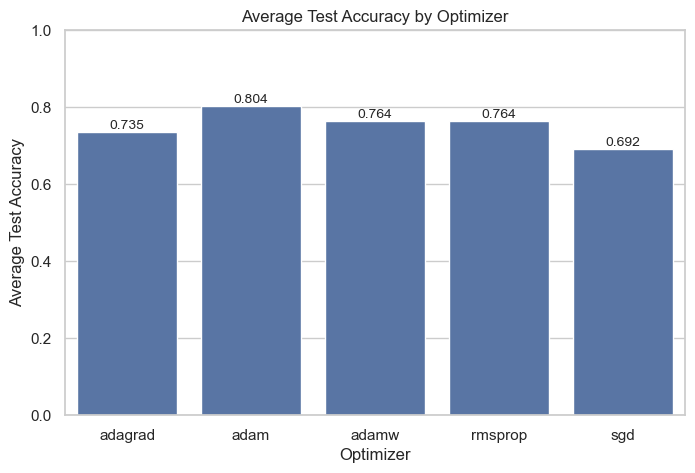

In [39]:
avg_test_acc = (
    results_df
    .groupby("optimizer", as_index=False)["test_accuracy"]
    .mean()
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=avg_test_acc,
    x="optimizer",
    y="test_accuracy"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Test Accuracy by Optimizer")
plt.xlabel("Optimizer")
plt.ylabel("Average Test Accuracy")
plt.ylim(0, 1)
plt.show()



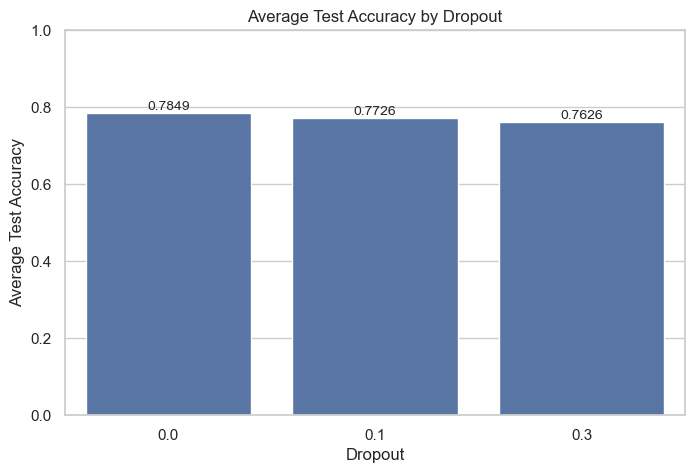

In [41]:
list30_models = (
    results_df
    .head(30)
    .copy()
)

avg_test_acc_dropout = (
    list30_models
    .groupby("dropout", as_index=False)["test_accuracy"]
    .mean()
    .sort_values("dropout")
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=avg_test_acc_dropout,
    x="dropout",
    y="test_accuracy"
)

# add exact values
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.4f}",
        (p.get_x() + p.get_width() / 2, value),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Dropout")
plt.ylabel("Average Test Accuracy")
plt.title("Average Test Accuracy by Dropout")
plt.ylim(0, 1)
plt.show()


In [49]:
top10_models = (
    results_df
    .sort_values(by="test_accuracy", ascending=False)
    .head(10)
)

display(top10_models)


,config,optimizer,learning_rate,activation,batch_norm,dropout,weight_init,epochs,best_val_accuracy,best_val_loss,test_accuracy,best_epoch
10,rmsprop0,rmsprop,0.001,relu,before,0.0,he,10,0.9399,0.1870,0.9163,9
71,adam_aug,adam,0.001,relu,before,0.1,he,10,0.9490,0.1501,0.9109,6
4,adam0,adam,0.001,relu,before,0.0,he,10,0.9495,0.1803,0.8953,1
57,rmsprop1,rmsprop,0.001,relu,before,0.1,uniform,10,0.9207,0.2131,0.8884,7
73,rmsprop_aug,rmsprop,0.001,relu,before,0.0,he,10,0.9405,0.1799,0.8858,7
63,adam1,adam,0.001,relu,before,0.1,xavier,10,0.9351,0.1933,0.8721,7
24,rmsprop,rmsprop,0.001,leaky_relu,before,0.1,he,10,0.9014,0.2435,0.8558,4
65,adamw1,adamw,0.001,relu,before,0.1,xavier,10,0.9423,0.1880,0.8488,7
5,adam1,adam,0.001,relu,before,0.3,he,10,0.9399,0.1843,0.8465,4
53,adam1,adam,0.001,relu,before,0.1,uniform,10,0.9399,0.1332,0.8372,10


In [43]:
from pathlib import Path

def create_model_name_from_row(row) -> str:
    lr = row["learning_rate"]
    dropout = row["dropout"]
    batch_norm_mode = row["batch_norm"]
    activation = row["activation"]
    init_weights_strategy = row["weight_init"]

    # mimic your formatting exactly
    lr_str = f"{lr:.0e}" if lr < 1e-2 else f"{lr}".replace(".", "x")
    dropout_str = f"{dropout}".replace(".", "x")
    batch_norm_str = (
        f"{batch_norm_mode}activation"
        if batch_norm_mode != "none"
        else "none"
    )

    config_stem = row["config"]

    return (
        f"{config_stem}_lr_{lr_str}"
        f"_dropout_{dropout_str}"
        f"_batchnorm_{batch_norm_str}"
        f"_{activation}_{init_weights_strategy}_weights.pth"
    )


In [51]:
top10_models = (
    results_df
    .sort_values("test_accuracy", ascending=False)
    .head(10)
    .copy()
)

top10_models["model_name"] = top10_models.apply(
    create_model_name_from_row,
    axis=1
)

top10_epochs = epochs_df[
    epochs_df["model_name"].isin(top10_models["model_name"])
].copy()

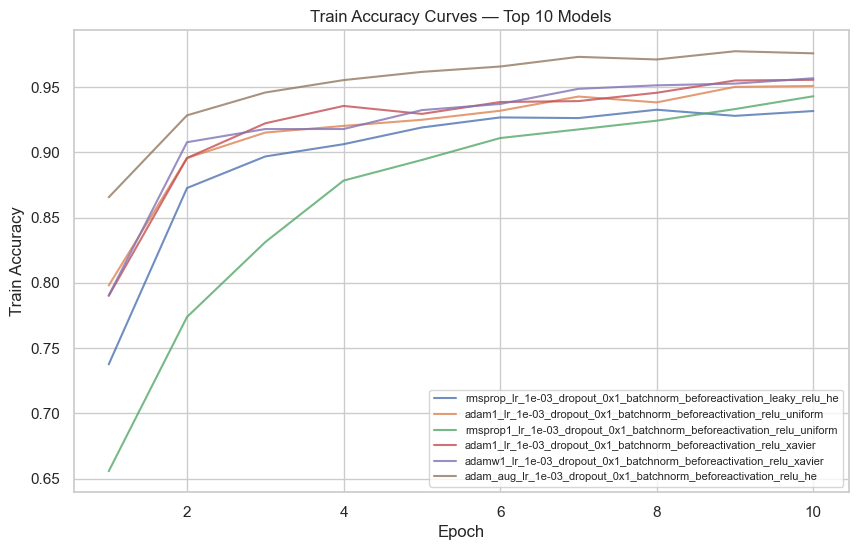

In [53]:
plt.figure(figsize=(10, 6))

for model_name in top10_epochs["model_name"].unique():
    model_epochs = top10_epochs[top10_epochs["model_name"] == model_name]
    
    plt.plot(
        model_epochs["epoch"],
        model_epochs["train_accuracy"],
        label=model_name.replace("_weights.pth", ""),
        alpha=0.8
    )

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.title("Train Accuracy Curves — Top 10 Models")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


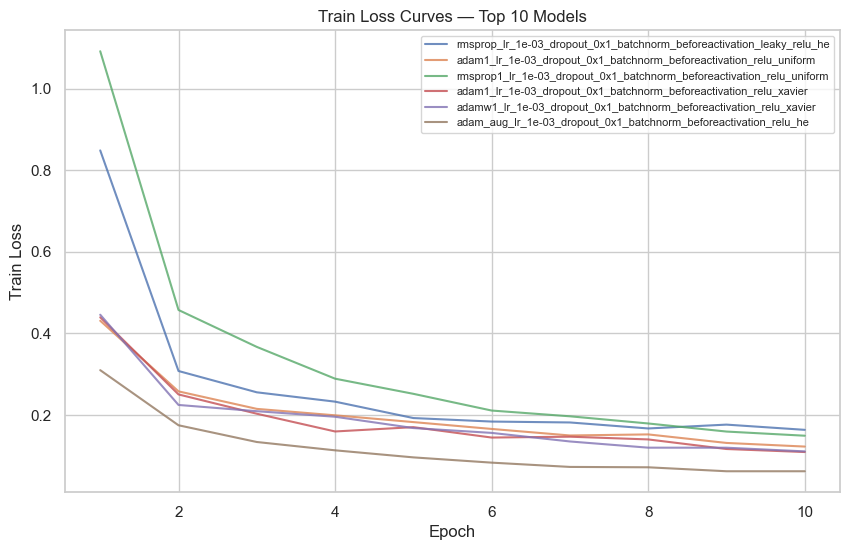

In [54]:
plt.figure(figsize=(10, 6))

for model_name in top10_epochs["model_name"].unique():
    model_epochs = top10_epochs[top10_epochs["model_name"] == model_name]
    
    plt.plot(
        model_epochs["epoch"],
        model_epochs["train_loss"],
        label=model_name.replace("_weights.pth", ""),
        alpha=0.8
    )

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss Curves — Top 10 Models")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

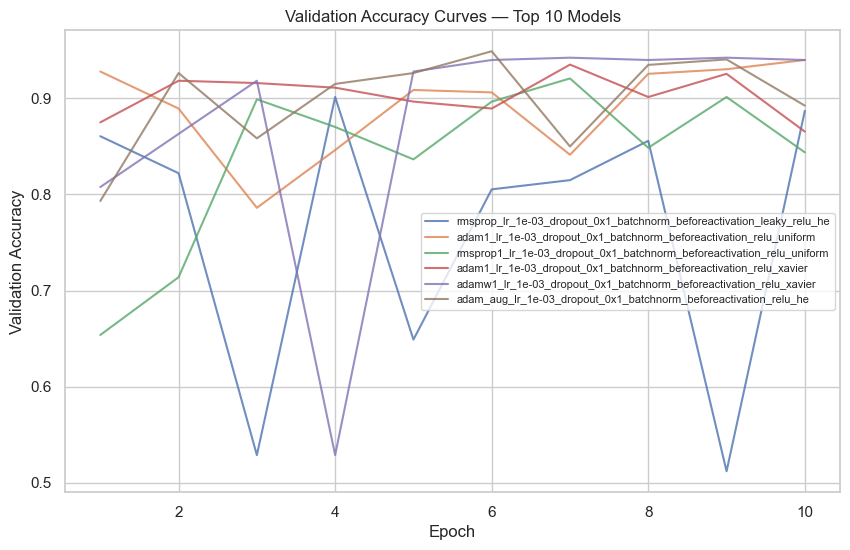

In [57]:
plt.figure(figsize=(10, 6))

for model_name in top10_epochs["model_name"].unique():
    model_epochs = top10_epochs[top10_epochs["model_name"] == model_name]
    
    plt.plot(
        model_epochs["epoch"],
        model_epochs["val_accuracy"],
        label=model_name.replace("_weights.pth", ""),
        alpha=0.8
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Curves — Top 10 Models")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


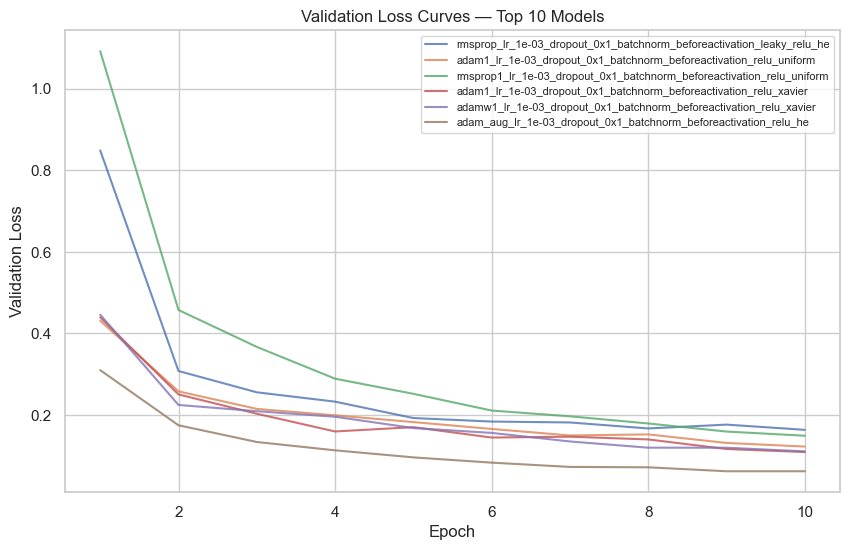

In [59]:
plt.figure(figsize=(10, 6))

for model_name in top10_epochs["model_name"].unique():
    model_epochs = top10_epochs[top10_epochs["model_name"] == model_name]
    
    plt.plot(
        model_epochs["epoch"],
        model_epochs["train_loss"],
        label=model_name.replace("_weights.pth", ""),
        alpha=0.8
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves — Top 10 Models")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

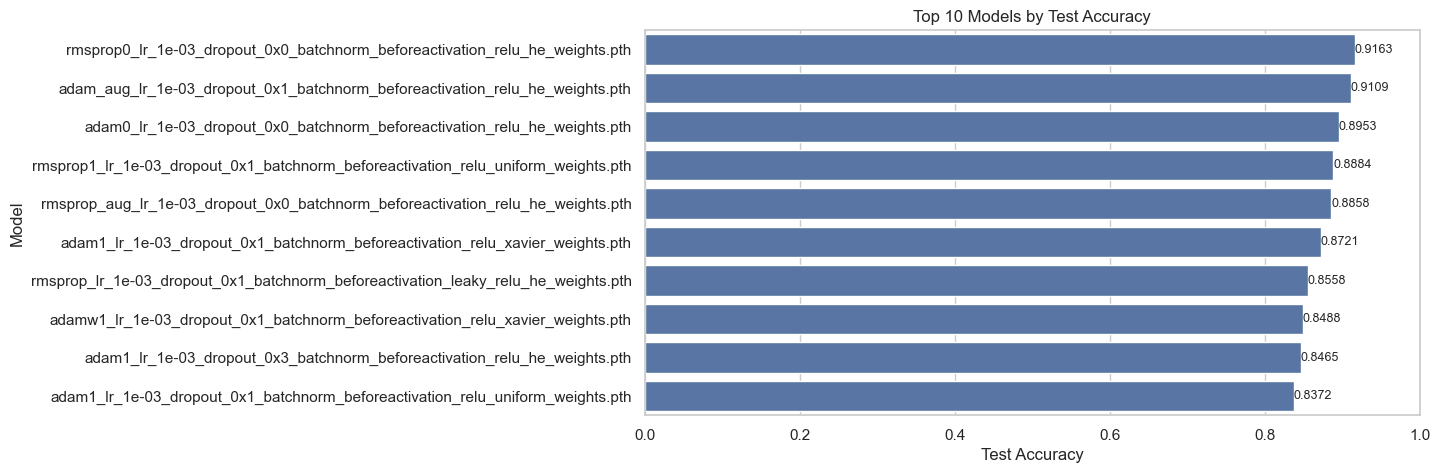

In [61]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top10_models,
    x="test_accuracy",
    y="model_name"
)

for p in ax.patches:
    value = p.get_width()
    ax.annotate(
        f"{value:.4f}",
        (value, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=9
    )

plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.title("Top 10 Models by Test Accuracy")
plt.xlim(0, 1)
plt.show()

```bash

```